# Instantaneous Rate of Change and the Derivative

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture motivating the **derivative**
(Week 1 — Derivatives and Optimization).

This notebook explains:

- the difference between **average** velocity and **instantaneous** velocity
- estimating the instantaneous velocity at a point by shrinking the interval
- the **secant slope** $\dfrac{\Delta x}{\Delta t}$ approaching the **tangent slope** $\dfrac{dx}{dt}$
- the **derivative** as the instantaneous rate of change = the slope of the tangent line
- a Python demonstration of secants converging to the tangent

This notebook follows the repository `GUIDELINES.md` template and sits at the start of the
derivatives material.

## 1. Introduction

Previously we computed the **average velocity** over an interval — total distance changed
divided by total time. But what is the velocity at a **single instant**?

> *"What is the instantaneous velocity at a point? Calculating it may be hard, but
> estimating it is possible."*

We focus on the point $t = 12.5$ on a distance–time curve.

After this notebook you will be able to:

- distinguish average from instantaneous rate of change
- estimate an instantaneous rate by shrinking the interval
- define the derivative as the slope of the tangent line

## 2. Average velocity = slope of a secant

Pick a second point to the **right** of $t = 12.5$ and compute the average velocity over
that interval:

$$
\text{average velocity} = \frac{\Delta x}{\Delta t}
= \frac{\text{change in distance}}{\text{change in time}} .
$$

Geometrically this is the slope of the **secant** line joining the two points. It is *not*
the instantaneous velocity at $t = 12.5$ — but it is an estimate.

We illustrate with a distance–time curve $x(t) = t^2$ (so the true velocity is $x'(t) =
2t$, giving $25$ at $t = 12.5$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def x(t):
    return t**2          # distance-time curve

t0 = 12.5

def average_velocity(t0, dt):
    return (x(t0 + dt) - x(t0)) / dt

for dt in [4, 2, 1, 0.5, 0.1, 0.01, 0.001]:
    print(f"Δt = {dt:>6}:  Δx/Δt = {average_velocity(t0, dt):.5f}")
print("\n-> as Δt shrinks, the average velocity approaches 25 (the instantaneous velocity).")

Δt =      4:  Δx/Δt = 29.00000
Δt =      2:  Δx/Δt = 27.00000
Δt =      1:  Δx/Δt = 26.00000
Δt =    0.5:  Δx/Δt = 25.50000
Δt =    0.1:  Δx/Δt = 25.10000
Δt =   0.01:  Δx/Δt = 25.01000
Δt =  0.001:  Δx/Δt = 25.00100

-> as Δt shrinks, the average velocity approaches 25 (the instantaneous velocity).


## 3. Shrinking the interval → the tangent

> *"You can get closer by making this interval smaller... put it so, so close that you
> can't even tell the distance between the two. So you get the limit, $dx/dt$ — the tangent
> line to the curve at $t = 12.5$."*

As $\Delta t \to 0$, the secant lines rotate toward the **tangent** line. Their slopes
converge to the **instantaneous rate of change**:

$$
\frac{dx}{dt} = \lim_{\Delta t \to 0} \frac{\Delta x}{\Delta t} .
$$

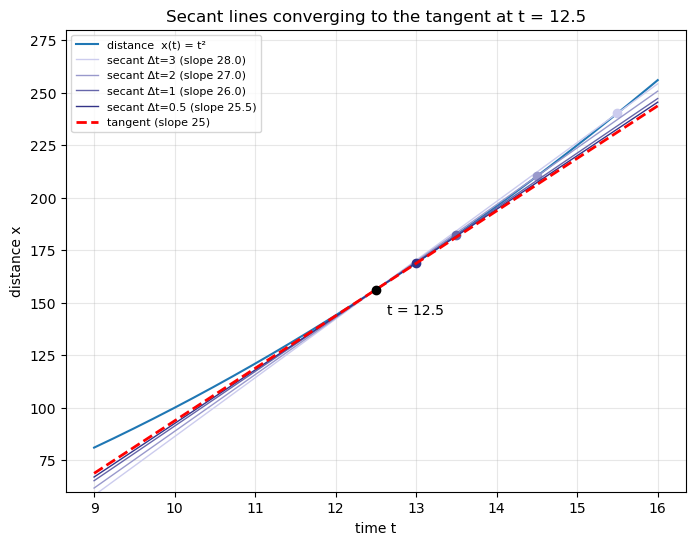

In [2]:
ts = np.linspace(9, 16, 200)

plt.figure(figsize=(8, 6))
plt.plot(ts, x(ts), label="distance  x(t) = t²")

# secant lines for shrinking Δt
for dt, col in zip([3, 2, 1, 0.5], ["#cce", "#99c", "#66a", "#338"]):
    slope = average_velocity(t0, dt)
    line = x(t0) + slope * (ts - t0)
    plt.plot(ts, line, color=col, lw=1, label=f"secant Δt={dt} (slope {slope:.1f})")
    plt.plot(t0 + dt, x(t0 + dt), "o", color=col)

# the tangent (slope 25)
plt.plot(ts, x(t0) + 25*(ts - t0), "r--", lw=2, label="tangent (slope 25)")
plt.plot(t0, x(t0), "ko")
plt.annotate("t = 12.5", (t0, x(t0)), textcoords="offset points", xytext=(8, -18))
plt.title("Secant lines converging to the tangent at t = 12.5")
plt.xlabel("time t"); plt.ylabel("distance x")
plt.ylim(60, 280); plt.grid(True, alpha=0.3); plt.legend(fontsize=8)
plt.show()

## 4. The derivative

> *"This measure of how fast the distance is changing with respect to time is called the
> instantaneous rate of change, and it is the slope of the tangent line. ... It's also
> called the derivative."*

More generally, the **instantaneous rate of change** of a function — how fast one variable
changes with respect to another at a point — is the **derivative**, the slope of the
tangent there:

$$
\frac{dx}{dt} = \lim_{\Delta t \to 0} \frac{x(t+\Delta t) - x(t)}{\Delta t}.
$$

Picture moving a tiny distance $dx$ in a tiny time $dt$: their ratio is the derivative.

In [3]:
# numerical derivative (central difference) vs the exact derivative x'(t)=2t
def numerical_derivative(f, t, h=1e-6):
    return (f(t + h) - f(t - h)) / (2 * h)

for t in [5.0, 12.5, 20.0]:
    print(f"t={t:>5}:  numeric x'(t) = {numerical_derivative(x, t):.5f},  exact 2t = {2*t:.1f}")

t=  5.0:  numeric x'(t) = 10.00000,  exact 2t = 10.0
t= 12.5:  numeric x'(t) = 25.00000,  exact 2t = 25.0
t= 20.0:  numeric x'(t) = 40.00000,  exact 2t = 40.0


## 5. Exercises

### Basic
1. What does the slope of a secant line represent?
2. What does the slope of the tangent line represent?

### Intermediate
3. For $x(t) = t^2$, compute the average velocity over $[12.5,\,12.5+\Delta t]$ for
   $\Delta t = 0.1$ and $\Delta t = 0.001$. What value are they approaching?
4. Write the limit definition of the derivative $\dfrac{dx}{dt}$.

### Advanced
5. For $x(t) = t^2$, show algebraically that $\dfrac{\Delta x}{\Delta t} = 2t_0 + \Delta t$
   over $[t_0,\,t_0+\Delta t]$, and take the limit as $\Delta t \to 0$.
6. Estimate the instantaneous velocity of $x(t) = \sin(t)$ at $t = 0$ numerically and
   compare to the exact value.

## 6. Solutions / Checks

In [4]:
# 3.
print(f"3. Δt=0.1   -> {average_velocity(12.5, 0.1):.5f}")
print(f"   Δt=0.001 -> {average_velocity(12.5, 0.001):.5f}  (approaching 25)")

# 5. algebra: (x(t0+dt)-x(t0))/dt = ((t0+dt)^2 - t0^2)/dt = (2 t0 dt + dt^2)/dt = 2 t0 + dt
import sympy as sp
t0s, dts = sp.symbols('t0 dt')
expr = ((t0s + dts)**2 - t0s**2) / dts
print("5. Δx/Δt =", sp.simplify(expr), " ->  limit dt->0 =", sp.limit(expr, dts, 0))

# 6. sin'(0)
print(f"6. numeric sin'(0) = {numerical_derivative(np.sin, 0.0):.6f}  (exact cos(0)=1)")

print("\n1. The average rate of change (average velocity) over the interval.")
print("2. The instantaneous rate of change (instantaneous velocity) = the derivative.")
print("4. dx/dt = lim_{Δt->0} (x(t+Δt) - x(t)) / Δt")

3. Δt=0.1   -> 25.10000
   Δt=0.001 -> 25.00100  (approaching 25)


5. Δx/Δt = dt + 2*t0  ->  limit dt->0 = 2*t0
6. numeric sin'(0) = 1.000000  (exact cos(0)=1)

1. The average rate of change (average velocity) over the interval.
2. The instantaneous rate of change (instantaneous velocity) = the derivative.
4. dx/dt = lim_{Δt->0} (x(t+Δt) - x(t)) / Δt


## 7. Conclusion

- **Average** velocity over an interval is the slope of a **secant**: $\Delta x/\Delta t$.
- Shrinking the interval, the secant slopes approach the slope of the **tangent** — the
  **instantaneous** velocity.
- That limiting slope is the **derivative**:
  $\dfrac{dx}{dt} = \lim_{\Delta t \to 0} \dfrac{\Delta x}{\Delta t}$.
- The derivative of a function at a point is precisely the **slope of the tangent** there —
  the foundational idea for everything that follows (optimization, gradients, gradient
  descent, and training models).

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (4).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture motivating the **derivative**. Key spoken points, lightly cleaned:

> We saw how to calculate average velocity over an interval; but what is the instantaneous
> velocity at a point such as $t = 12.5$? Estimating it is possible: take a second point to
> the right and compute the average velocity over that interval — the slope $\Delta x /
> \Delta t$. That isn't the instantaneous velocity, but making the interval smaller gets you
> closer; each smaller interval gives a new secant slope. Push the second point so close
> that the gap vanishes and you get the limit $dx/dt$ — the slope of the tangent line at $t
> = 12.5$. This instantaneous rate of change is the slope of the tangent, and it measures
> how fast the relation between two variables changes at a point. Moving a tiny distance
> $dx$ in a tiny time $dt$, their ratio is the instantaneous rate of change — also called
> the derivative. The derivative of a function at a point is exactly the slope of the
> tangent there.